In [8]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
df = pd.read_excel(
    "twitter_training.xlsx",
    header=None,
    names=["ID","Topic","Sentiment","Tweet"]
)

df.head()

,ID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [10]:
print("Shape:", df.shape)

print("\nSentiment Counts:")
print(df["Sentiment"].value_counts())

df.info()

Shape: (74682, 4)

Sentiment Counts:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Topic      74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [11]:
df = df[df["Sentiment"].isin(["Positive","Negative"])]

print(df["Sentiment"].value_counts())

Sentiment
Negative    22542
Positive    20832
Name: count, dtype: int64


In [12]:
df["Sentiment"] = df["Sentiment"].map({
    "Negative":0,
    "Positive":1
})

In [13]:
print(df.isnull().sum())

df.dropna(inplace=True)

ID             0
Topic          0
Sentiment      0
Tweet        361
dtype: int64


In [14]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\\S+","",text)

    text = re.sub(r"[^a-zA-Z ]"," ",text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [15]:
df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

df[["Tweet","Clean_Tweet"]].head()

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im get borderland murder
1,I am coming to the borders and I will kill you...,come border kill
2,im getting on borderlands and i will kill you ...,im get borderland kill
3,im coming on borderlands and i will murder you...,im come borderland murder
4,im getting on borderlands 2 and i will murder ...,im get borderland murder


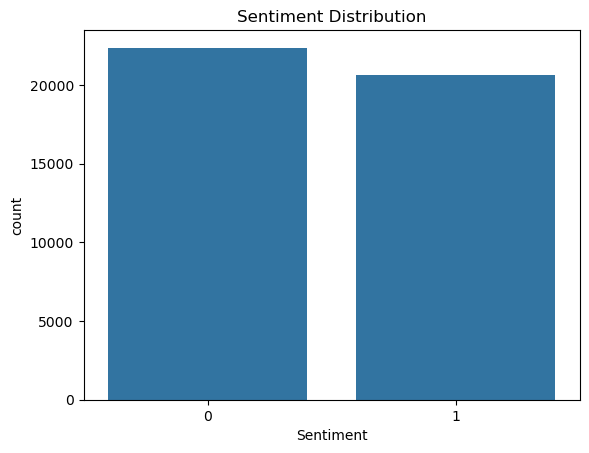

In [16]:
sns.countplot(x=df["Sentiment"])

plt.title("Sentiment Distribution")

plt.show()

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["Clean_Tweet"])

y = df["Sentiment"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [20]:
pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,pred)

print("Accuracy =", accuracy)

Accuracy = 0.8521446007206789


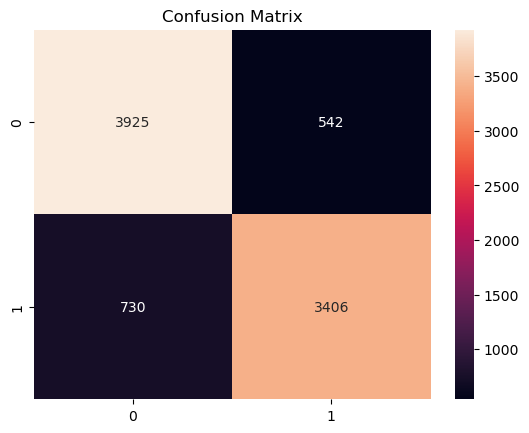

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      4467
           1       0.86      0.82      0.84      4136

    accuracy                           0.85      8603
   macro avg       0.85      0.85      0.85      8603
weighted avg       0.85      0.85      0.85      8603



In [24]:
tweet = "I love this game"

cleaned = clean_text(tweet)

vector = vectorizer.transform([cleaned])

result = model.predict(vector)

if result[0] == 1:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😞")

Positive Tweet 😊


In [25]:
tweet = "This game is terrible and boring"

cleaned = clean_text(tweet)

vector = vectorizer.transform([cleaned])

result = model.predict(vector)

if result[0] == 1:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😞")

Negative Tweet 😞
